# Project: Quantifying "Expected Danger" in the Premier League
**Author:** Hannah Nyarkoa Oduro  
**Date:** January 2026  
## 1. Project Goal
To build a Machine Learning model that identifies the most dangerous passers in the Premier League. Instead of counting simple assists, we value every pass based on:
1.  **Probability:** How likely is a shot to occur from this pass?
2.  **Quality:** How dangerous (xG) is the resulting shot likely to be?
## 2. Methodology
* **Data:** 380 Matches of Wyscout Event Data (Premier League).
* **Model A (Logistic Regression):** Predicts `Probability of Shot`.
* **Model B (Linear Regression):** Predicts `Expected xG`.
* **Metric:** `Expected Danger = Probability × xG`

In [2]:
import pandas as pd
import numpy as np
import json
import glob
import os
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [3]:
#  1. SETUP & LOAD DATA 
print(" STEP 1: LOADING DATA ")

try:
    players = pd.read_parquet('players.parquet')
    minutes = pd.read_parquet('minutes.parquet')
    print(f"Metadata Loaded: {len(players)} players found.")
except FileNotFoundError:
    print("ERROR: Parquet files not found. Are you sure your notebook is in C:\\SoccerData\\PL_2024_course?")

# Load Event JSONs
def load_events():
    all_events = []
    # Check for 'event_data' (singular) or 'events_data' (plural)
    folder_name = 'event_data' if os.path.exists('event_data') else 'events_data'
    
    json_files = glob.glob(os.path.join(folder_name, '*.json'))
    print(f"Parsing {len(json_files)} match files from '{folder_name}'...")
    
    for filename in json_files:
        with open(filename, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                # Wyscout data often wraps events in a dictionary key 'events'
                if isinstance(data, dict) and 'events' in data:
                    all_events.extend(data['events'])
                else:
                    all_events.extend(data)
            except:
                pass 
    return pd.DataFrame(all_events)

df = load_events()
print(f"Total Events Loaded: {len(df)}")

 STEP 1: LOADING DATA 
Metadata Loaded: 684 players found.
Parsing 380 match files from 'event_data'...
Total Events Loaded: 630260


In [6]:
print("Diagnosing columns...")
print(f"Existing columns: {df.columns.tolist()}")

if 'event_name' in df.columns:
    print("Found 'event_name'. Renaming to 'eventName'...")
    df.rename(columns={'event_name': 'eventName'}, inplace=True)

elif 'type' in df.columns:
    print("Found 'type' column. Extracting event name from it...")
    
    # Function to pull the name out of the dictionary
    def extract_name(val):
        if isinstance(val, dict) and 'primary' in val:
            return val['primary']
        return val # If it's already a string
        
    df['eventName'] = df['type'].apply(extract_name)

elif 'label' in df.columns:
    print("Found 'label'. Renaming to 'eventName'...")
    df.rename(columns={'label': 'eventName'}, inplace=True)

if 'eventName' in df.columns:
    print("\nSUCCESS: 'eventName' column is now ready.")
    print(df[['eventName', 'x_m', 'y_m']].head())
else:
    print("\nCRITICAL: Could not find the event name column automatically.")
    print("Please paste the list of columns printed above so I can tell you which one to use.")

Diagnosing columns...
Existing columns: ['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp', 'videoTimestamp', 'relatedEventId', 'type', 'location', 'team', 'opponentTeam', 'player', 'pass', 'shot', 'groundDuel', 'aerialDuel', 'infraction', 'carry', 'possession', 'eventName', 'x', 'y', 'x_m', 'y_m', 'end_x', 'end_y', 'end_x_m', 'end_y_m', 'dist_to_goal', 'angle_to_goal']
Found 'type' column. Extracting event name from it...

SUCCESS: 'eventName' column is now ready.
  eventName    x_m    y_m
0      pass  53.55  34.00
1      pass  39.90  41.48
2      pass  25.20  55.08
3      duel  67.20  61.88
4      duel  37.80   6.12


In [5]:
#  STEP 2 
print("Fixing coordinates using 'location' column...")

# data uses a 'location' column which usually looks like: {'x': 50, 'y': 50}
def get_coords_v2(row):
    loc = row.get('location', {})
    
    # If location is missing or not a dict, return NaNs
    if not isinstance(loc, dict):
        return pd.Series([np.nan, np.nan])
        
    return pd.Series([loc.get('x'), loc.get('y')])

# Applying the new function
df[['x', 'y']] = df.apply(get_coords_v2, axis=1)

# applying the conversions
df['x_m'] = df['x'] * 1.05
df['y_m'] = df['y'] * 0.68

# For 'end' coordinates, checking if they exist in 'pass' or 'shot' columns
def get_end_coords(row):
    pass_info = row.get('pass', {})
    if isinstance(pass_info, dict) and 'endLocation' in pass_info:
        end_loc = pass_info['endLocation']
        return pd.Series([end_loc.get('x'), end_loc.get('y')])
    
    # If shot, check shot info (though shots usually don't have end_x like passes)
    return pd.Series([np.nan, np.nan])

df[['end_x', 'end_y']] = df.apply(get_end_coords, axis=1)

# Converting end coords
df['end_x_m'] = df['end_x'] * 1.05
df['end_y_m'] = df['end_y'] * 0.68

# Recalculating Distance & Angle
df['dist_to_goal'] = np.sqrt((105 - df['end_x_m'])**2 + (34 - df['end_y_m'])**2)
df['angle_to_goal'] = np.arctan2(34 - df['end_y_m'], 105 - df['end_x_m'])

print("Coordinates Fixed.")
print(df[['eventName', 'x_m', 'y_m', 'dist_to_goal']].head())

Fixing coordinates using 'location' column...
Coordinates Fixed.
  eventName    x_m    y_m  dist_to_goal
0      pass  53.55  34.00     65.528318
1      pass  39.90  41.48     82.537303
2      pass  25.20  55.08     46.969505
3      duel  67.20  61.88           NaN
4      duel  37.80   6.12           NaN


In [7]:
#  STEP 3: LINKING PASSES TO SHOTS 
print("Running Step 3: Linking Passes to Shots...")

# 1. Filtering for Passes and Shots
passes = df[df['eventName'] == 'pass'].copy()
shots = df[df['eventName'] == 'shot'].copy()

# 2. Creating a 'Time in Seconds' column
passes['eventSec'] = (passes['minute'] * 60) + passes['second']
shots['eventSec'] = (shots['minute'] * 60) + shots['second']

# 3. Sorting by Match and Time
passes = passes.sort_values(['matchId', 'matchPeriod', 'eventSec'])
shots = shots.sort_values(['matchId', 'matchPeriod', 'eventSec'])

# 4. Initialize columns
passes['shot_within_15s'] = 0
passes['shot_xg'] = 0.0

print(f"Analyzing {len(passes)} passes and {len(shots)} shots...")

# 5. The Linking Loop
for i, shot in shots.iterrows():
    
    # Defining the 15-second window
    mask = (
        (passes['matchId'] == shot['matchId']) & 
        (passes['matchPeriod'] == shot['matchPeriod']) & 
        (passes['eventSec'] < shot['eventSec']) & 
        (passes['eventSec'] >= shot['eventSec'] - 15)
    )
    
    # Marking those passes as successful
    passes.loc[mask, 'shot_within_15s'] = 1
    
    # Extracting xG from the shot dictionary if available
    xg_val = 0.0
    shot_data = shot.get('shot', {})
    if isinstance(shot_data, dict):
        xg_val = shot_data.get('xg', 0.0)
        
    passes.loc[mask, 'shot_xg'] = xg_val

count = passes['shot_within_15s'].sum()
print(f"Success! Found {count} passes that led to a shot.")

Running Step 3: Linking Passes to Shots...
Analyzing 320903 passes and 8750 shots...
Success! Found 26561 passes that led to a shot.


In [8]:
# STEP 4 & 5: MODELS AND FINAL RANKING
print("Running Step 4 & 5: Modelling and Ranking...")

Running Step 4 & 5: Modelling and Ranking...


In [9]:
# 1. Preparing Data for Modelling
# Removing passes with missing coordinates (NaNs) so the model doesn't crash
model_data = passes.dropna(subset=['x_m', 'y_m', 'end_x_m', 'end_y_m', 'dist_to_goal'])

In [10]:
# 2. Model A: Probability of a Shot (Logistic Regression)
# "What is the % chance this pass leads to a shot?"
print("Training Model A (Shot Probability)...")
formula_prob = "shot_within_15s ~ x_m + y_m + end_x_m + end_y_m + dist_to_goal"
model_prob = smf.logit(formula_prob, data=model_data).fit(disp=0)

Training Model A (Shot Probability)...


In [11]:
# Applying prediction to ALL passes
passes['prob_shot'] = model_prob.predict(passes)

# 3. Model B: Expected xG (Linear Regression)
# "If a shot happens, how dangerous is it usually?" (Trained ONLY on successful passes)
print("Training Model B (Expected xG)...")
successful_passes = model_data[model_data['shot_within_15s'] == 1]
model_xg = smf.ols("shot_xg ~ end_x_m + end_y_m + dist_to_goal", data=successful_passes).fit()

# Apply prediction to ALL passes
passes['pred_xg'] = model_xg.predict(passes)

Training Model B (Expected xG)...


In [12]:
4. # Calculating EXPECTED DANGER 
# Probability * Value = Expected Danger
passes['expected_danger'] = passes['prob_shot'] * passes['pred_xg']

print("Models trained. Calculating rankings...")

Models trained. Calculating rankings...


In [13]:
print("Columns in players table:")
print(players.columns.tolist())

Columns in players table:
['player_id', 'short_name', 'first_name', 'last_name', 'birth_date', 'height', 'weight', 'passport', 'birth_country', 'image_url', 'gender', 'foot', 'role', 'team_id', 'season_id']


In [14]:
#  AGGREGATE & RANK ONLY 
print("calculating rankings...")

# 1. Extracting Player ID from passes 
if 'playerId' not in passes.columns:
    def get_id(row):
        p = row.get('player', {})
        return p.get('id') if isinstance(p, dict) else np.nan
    passes['playerId'] = passes.apply(get_id, axis=1)

# 2. Group by Player
stats = passes.groupby('playerId').agg(
    total_ed=('expected_danger', 'sum'),
    total_passes=('expected_danger', 'count')
).reset_index()

# 3. Convert ID to integer
stats['playerId'] = stats['playerId'].dropna().astype(int)

# 4. Merge with Player Names
# Using 'player_id' as we discovered earlier
stats = stats.merge(players, left_on='playerId', right_on='player_id', how='left')

# 5. Merge with Minutes
# checking if the column is 'playerId' or 'player_id'
min_col = 'player_id' if 'player_id' in minutes.columns else 'playerId'
print(f"Grouping minutes using column: '{min_col}'")

minutes_agg = minutes.groupby(min_col)['minutes'].sum().reset_index()

# Renaming the column to 'playerId' temporarily to make the merge easy
minutes_agg = minutes_agg.rename(columns={min_col: 'playerId'})
stats = stats.merge(minutes_agg, on='playerId', how='left')

# 6. Calculate Per 90
stats['ed_per_90'] = (stats['total_ed'] / stats['minutes']) * 90

# 7. Final Output
final_ranking = stats[stats['minutes'] > 500].sort_values('ed_per_90', ascending=False)

print("\n TOP 15 PLAYERS (EXPECTED DANGER PER 90) ---")
print(final_ranking[['short_name', 'ed_per_90', 'minutes']].head(15).to_string(index=False))

calculating rankings...
Grouping minutes using column: 'player_id'

 TOP 15 PLAYERS (EXPECTED DANGER PER 90) ---
         short_name  ed_per_90  minutes
         T. Cairney   0.930822    627.0
         M. Kovačić   0.917389   2230.0
       K. De Bruyne   0.875376   1708.0
        J. Grealish   0.820893    708.0
            J. Doku   0.808283   1522.0
         Rúben Dias   0.805986   2269.0
T. Alexander-Arnold   0.792626   2370.0
       O. Zinchenko   0.790118    522.0
        M. Ødegaard   0.777326   2332.0
      Nico González   0.761414    757.0
        İ. Gündoğan   0.736625   2227.0
          M. Akanji   0.735061   2015.0
          K. Walker   0.726360    966.0
        J. Gvardiol   0.718117   3281.0
      Matheus Nunes   0.716345   1669.0


In [15]:
# VIEW MODEL SUMMARIES 

print("==========================================")
print("MODEL 1: LOGISTIC REGRESSION (Shot Probability)")
print("==========================================")
# This shows how location affects the CHANCE of a shot happening
print(model_prob.summary())

print("\n\n")
print("==========================================")
print("MODEL 2: LINEAR REGRESSION (Expected xG)")
print("==========================================")
# This shows how location affects the QUALITY of the shot (if one happens)
print(model_xg.summary())

MODEL 1: LOGISTIC REGRESSION (Shot Probability)
                           Logit Regression Results                           
Dep. Variable:        shot_within_15s   No. Observations:               320903
Model:                          Logit   Df Residuals:                   320897
Method:                           MLE   Df Model:                            5
Date:                Fri, 09 Jan 2026   Pseudo R-squ.:                 0.07648
Time:                        21:08:48   Log-Likelihood:                -84605.
converged:                       True   LL-Null:                       -91612.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.5630      0.150     17.041      0.000       2.268       2.858
x_m              0.0048      0.000     10.405      0.000       0.004       0.

Results saved to 'expected_danger_results.csv'


C:\Users\HP\AppData\Local\Temp\ipykernel_11360\1249542677.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


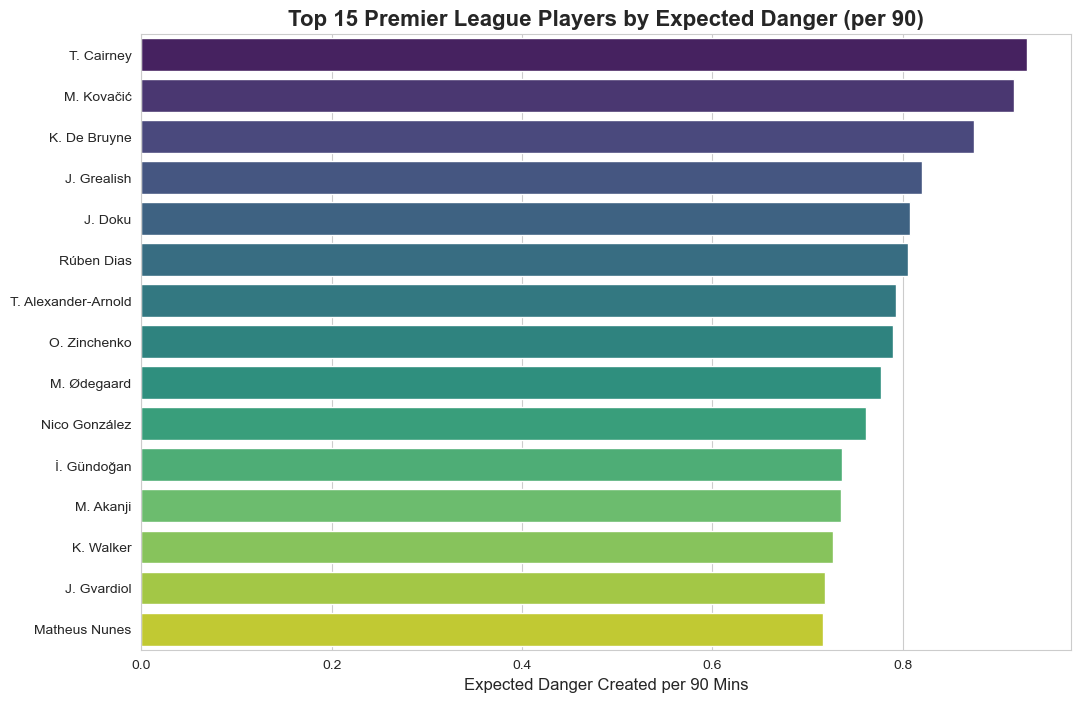

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SAVE TO EXCEL/CSV 
final_ranking.to_csv('expected_danger_results.csv', index=False)
print("Results saved to 'expected_danger_results.csv'")

# 2. CREATE A BAR CHART 
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the barplot
sns.barplot(
    x='ed_per_90', 
    y='short_name', 
    data=final_ranking.head(15),
    palette='viridis'
)

plt.title('Top 15 Premier League Players by Expected Danger (per 90)', fontsize=16, fontweight='bold')
plt.xlabel('Expected Danger Created per 90 Mins', fontsize=12)
plt.ylabel('')
plt.show()